# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan

## Jaya Jaya Institut - Student Dropout Prediction

**Nama:** Pratama  
**Email:** josapratama@example.com  
**Dataset:** [Students' Performance](https://github.com/dicodingacademy/dicoding_dataset/blob/main/students_performance/README.md)

---

## 1. Business Understanding

### Latar Belakang
Jaya Jaya Institut adalah institusi pendidikan perguruan tinggi yang berdiri sejak tahun 2000. Meskipun telah mencetak banyak lulusan dengan reputasi baik, institusi ini menghadapi masalah serius: **tingginya angka dropout mahasiswa**. Jumlah dropout yang tinggi berdampak negatif terhadap reputasi institusi, pendapatan, dan kualitas pendidikan secara keseluruhan.

### Permasalahan Bisnis
1. Seberapa besar tingkat dropout mahasiswa di Jaya Jaya Institut?
2. Faktor-faktor apa saja yang paling berpengaruh terhadap keputusan mahasiswa untuk dropout?
3. Bagaimana cara memprediksi sedini mungkin mahasiswa yang berpotensi dropout sehingga dapat diberikan intervensi?

### Cakupan Proyek
- Analisis eksploratif data (EDA) untuk memahami distribusi dan pola dropout
- Pembangunan model machine learning untuk memprediksi risiko dropout (Dropout vs Graduate)
- Pembuatan dashboard monitoring performa mahasiswa menggunakan Metabase
- Deployment prototype sistem prediksi berbasis Streamlit

### Persiapan
**Sumber data:** Dataset Students' Performance dari Dicoding Academy  
**Setup environment:**
```
conda create --name main-ds python=3.9
conda activate main-ds
pip install -r requirements.txt
```

## 2. Import Library

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, f1_score, ConfusionMatrixDisplay
)

# Model persistence
import joblib
import json
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Libraries imported successfully!')

Libraries imported successfully!


## 3. Data Understanding

### Load Dataset

In [2]:
# Load dataset
df = pd.read_csv('data.csv', delimiter=';')

print(f'Shape dataset: {df.shape}')
print(f'Jumlah baris  : {df.shape[0]}')
print(f'Jumlah kolom  : {df.shape[1]}')
print(f'\nDistribusi Status:')
print(df['Status'].value_counts())
df.head()

Shape dataset: (4424, 37)
Jumlah baris  : 4424
Jumlah kolom  : 37

Distribusi Status:
Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.00,1,19,12,5,9,127.30,1,0,0,1,1,0,20,0,0,0,0,0,0.00,0,0,0,0,0,0.00,0,10.80,1.40,1.74,Dropout
1,1,15,1,9254,1,1,160.00,1,1,3,3,3,142.50,1,0,0,0,1,0,19,0,0,6,6,6,14.00,0,0,6,6,6,13.67,0,13.90,-0.30,0.79,Graduate
2,1,1,5,9070,1,1,122.00,1,37,37,9,9,124.80,1,0,0,0,1,0,19,0,0,6,0,0,0.00,0,0,6,0,0,0.00,0,10.80,1.40,1.74,Dropout
3,1,17,2,9773,1,1,122.00,1,38,37,5,3,119.60,1,0,0,1,0,0,20,0,0,6,8,6,13.43,0,0,6,10,5,12.40,0,9.40,-0.80,-3.12,Graduate
4,2,39,1,8014,0,1,100.00,1,37,38,9,9,141.50,0,0,0,1,0,0,45,0,0,6,9,5,12.33,0,0,6,6,6,13.00,0,13.90,-0.30,0.79,Graduate


In [3]:
# Info & statistik deskriptif
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [4]:
df.describe()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00
mean,1.18,18.67,1.73,8856.64,0.89,4.58,132.61,1.87,19.56,22.28,10.96,11.03,126.98,0.55,0.01,0.11,0.88,0.35,0.25,23.27,0.02,0.71,6.27,8.30,4.71,10.64,0.14,0.54,6.23,8.06,4.44,10.23,0.15,11.57,1.23,0.00
std,0.61,17.48,1.31,2063.57,0.31,10.22,13.19,6.91,15.60,15.34,26.42,25.26,14.48,0.50,0.11,0.32,0.32,0.48,0.43,7.59,0.16,2.36,2.48,4.18,3.09,4.84,0.69,1.92,2.20,3.95,3.01,5.21,0.75,2.66,1.38,2.27
min,1.00,1.00,0.00,33.00,0.00,1.00,95.00,1.00,1.00,1.00,0.00,0.00,95.00,0.00,0.00,0.00,0.00,0.00,0.00,17.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,7.60,-0.80,-4.06
25%,1.00,1.00,1.00,9085.00,1.00,1.00,125.00,1.00,2.00,3.00,4.00,4.00,117.90,0.00,0.00,0.00,1.00,0.00,0.00,19.00,0.00,0.00,5.00,6.00,3.00,11.00,0.00,0.00,5.00,6.00,2.00,10.75,0.00,9.40,0.30,-1.70
50%,1.00,17.00,1.00,9238.00,1.00,1.00,133.10,1.00,19.00,19.00,5.00,7.00,126.10,1.00,0.00,0.00,1.00,0.00,0.00,20.00,0.00,0.00,6.00,8.00,5.00,12.29,0.00,0.00,6.00,8.00,5.00,12.20,0.00,11.10,1.40,0.32
75%,1.00,39.00,2.00,9556.00,1.00,1.00,140.00,1.00,37.00,37.00,9.00,9.00,134.80,1.00,0.00,0.00,1.00,1.00,0.00,25.00,0.00,0.00,7.00,10.00,6.00,13.40,0.00,0.00,7.00,10.00,6.00,13.33,0.00,13.90,2.60,1.79
max,6.00,57.00,9.00,9991.00,1.00,43.00,190.00,109.00,44.00,44.00,194.00,195.00,190.00,1.00,1.00,1.00,1.00,1.00,1.00,70.00,1.00,20.00,26.00,45.00,26.00,18.88,12.00,19.00,23.00,33.00,20.00,18.57,12.00,16.20,3.70,3.51


### Distribusi Target Variable

Distribusi Status Mahasiswa (seluruh data):
  Graduate: 2209 (49.9%)
  Dropout: 1421 (32.1%)
  Enrolled: 794 (17.9%)


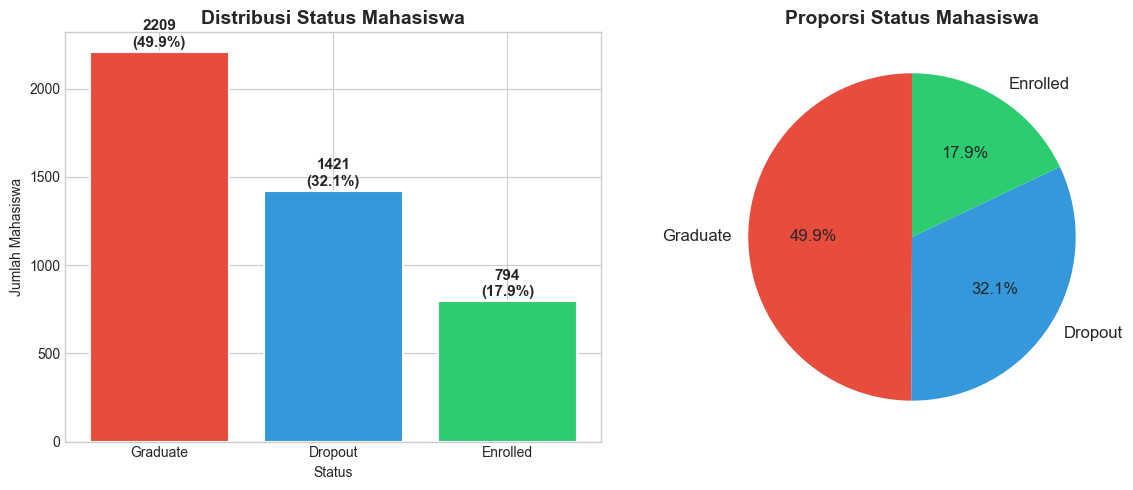


Catatan: Data Enrolled TIDAK akan digunakan dalam training model.
Model hanya dilatih pada data Dropout vs Graduate.
Data Enrolled disimpan terpisah untuk prediksi masa depan.


In [5]:
# Distribusi target
target_counts = df['Status'].value_counts()
target_pct    = df['Status'].value_counts(normalize=True) * 100

print('Distribusi Status Mahasiswa (seluruh data):')
for s in target_counts.index:
    print(f'  {s}: {target_counts[s]} ({target_pct[s]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#e74c3c', '#3498db', '#2ecc71']

axes[0].bar(target_counts.index, target_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribusi Status Mahasiswa', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Status'); axes[0].set_ylabel('Jumlah Mahasiswa')
for i, (v, p) in enumerate(zip(target_counts.values, target_pct.values)):
    axes[0].text(i, v + 30, f'{v}\n({p:.1f}%)', ha='center', fontsize=11, fontweight='bold')

axes[1].pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Proporsi Status Mahasiswa', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('pratama_dicoding-dashboard/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCatatan: Data Enrolled TIDAK akan digunakan dalam training model.')
print('Model hanya dilatih pada data Dropout vs Graduate.')
print('Data Enrolled disimpan terpisah untuk prediksi masa depan.')

## 4. Exploratory Data Analysis (EDA)

### 4.1 Missing Values & Duplicates

In [6]:
missing = df.isnull().sum()
print('Missing Values:')
print(missing[missing > 0] if missing.sum() > 0 else 'Tidak ada missing values!')
print(f'\nJumlah duplikat: {df.duplicated().sum()}')

Missing Values:
Tidak ada missing values!

Jumlah duplikat: 0


### 4.2 Analisis Faktor Demografis

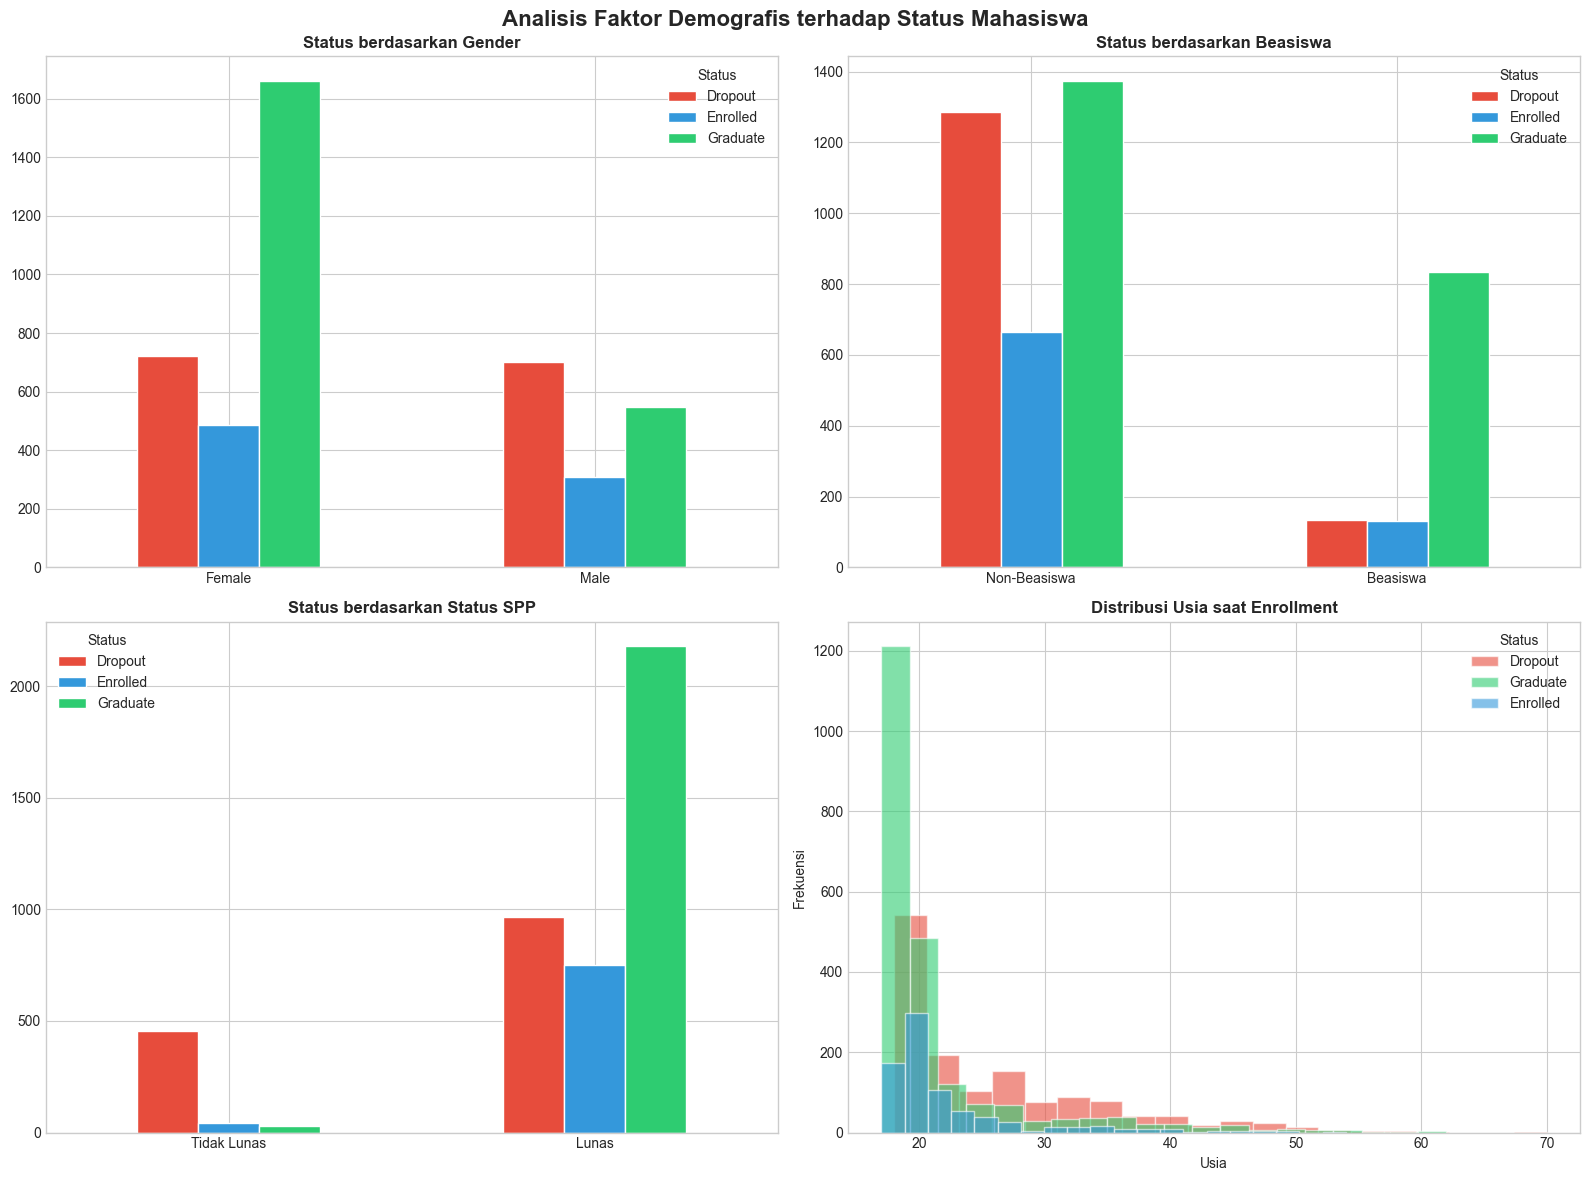

Insight: SPP tidak lunas dan tidak dapat beasiswa meningkatkan risiko dropout.


In [7]:
# EDA pada seluruh data (termasuk Enrolled) untuk memahami konteks
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Analisis Faktor Demografis terhadap Status Mahasiswa', fontsize=16, fontweight='bold')

colors_s = {'Dropout': '#e74c3c', 'Graduate': '#2ecc71', 'Enrolled': '#3498db'}

# 1. Gender
g = df.groupby(['Gender', 'Status']).size().unstack(fill_value=0)
g.index = ['Female', 'Male']
g.plot(kind='bar', ax=axes[0,0], color=[colors_s[c] for c in g.columns], edgecolor='white')
axes[0,0].set_title('Status berdasarkan Gender', fontsize=12, fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=0)
axes[0,0].legend(title='Status')

# 2. Beasiswa
s = df.groupby(['Scholarship_holder', 'Status']).size().unstack(fill_value=0)
s.index = ['Non-Beasiswa', 'Beasiswa']
s.plot(kind='bar', ax=axes[0,1], color=[colors_s[c] for c in s.columns], edgecolor='white')
axes[0,1].set_title('Status berdasarkan Beasiswa', fontsize=12, fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=0)
axes[0,1].legend(title='Status')

# 3. SPP
t = df.groupby(['Tuition_fees_up_to_date', 'Status']).size().unstack(fill_value=0)
t.index = ['Tidak Lunas', 'Lunas']
t.plot(kind='bar', ax=axes[1,0], color=[colors_s[c] for c in t.columns], edgecolor='white')
axes[1,0].set_title('Status berdasarkan Status SPP', fontsize=12, fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=0)
axes[1,0].legend(title='Status')

# 4. Usia
for status, color in colors_s.items():
    axes[1,1].hist(df[df['Status']==status]['Age_at_enrollment'],
                   alpha=0.6, label=status, bins=20, color=color, edgecolor='white')
axes[1,1].set_title('Distribusi Usia saat Enrollment', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Usia'); axes[1,1].set_ylabel('Frekuensi')
axes[1,1].legend(title='Status')

plt.tight_layout()
plt.savefig('pratama_dicoding-dashboard/demographic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: SPP tidak lunas dan tidak dapat beasiswa meningkatkan risiko dropout.')

### 4.3 Analisis Performa Akademik

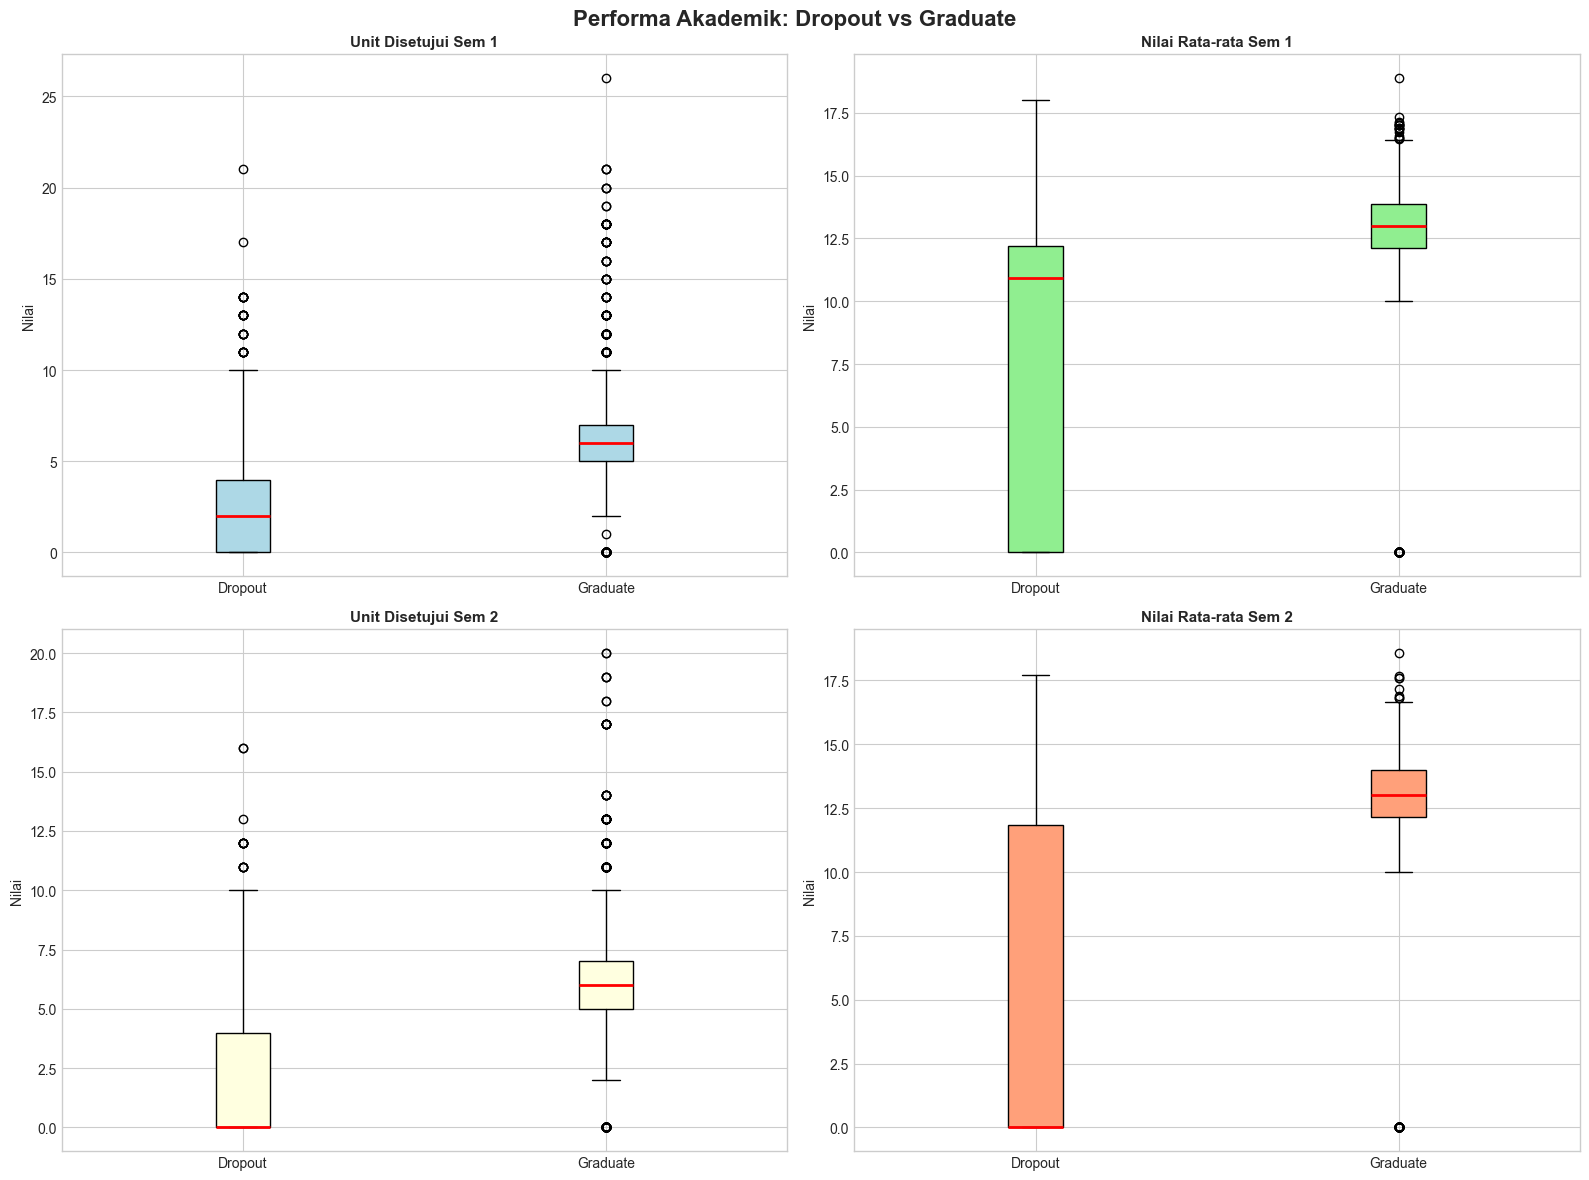

Insight: Mahasiswa Dropout konsisten memiliki nilai dan unit disetujui yang jauh lebih rendah.


In [8]:
# Fokus perbandingan Dropout vs Graduate
df_dg = df[df['Status'].isin(['Dropout', 'Graduate'])].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Performa Akademik: Dropout vs Graduate', fontsize=16, fontweight='bold')

pairs = [
    ('Curricular_units_1st_sem_approved', 'Unit Disetujui Sem 1', 'lightblue'),
    ('Curricular_units_1st_sem_grade',    'Nilai Rata-rata Sem 1', 'lightgreen'),
    ('Curricular_units_2nd_sem_approved', 'Unit Disetujui Sem 2', 'lightyellow'),
    ('Curricular_units_2nd_sem_grade',    'Nilai Rata-rata Sem 2', 'lightsalmon'),
]
for ax, (col, title, fc) in zip(axes.flat, pairs):
    data = [df_dg[df_dg['Status']==s][col].values for s in ['Dropout','Graduate']]
    bp = ax.boxplot(data, labels=['Dropout','Graduate'], patch_artist=True)
    for patch in bp['boxes']: patch.set_facecolor(fc)
    for med in bp['medians']: med.set_color('red'); med.set_linewidth(2)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Nilai')

plt.tight_layout()
plt.savefig('pratama_dicoding-dashboard/academic_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Mahasiswa Dropout konsisten memiliki nilai dan unit disetujui yang jauh lebih rendah.')

### 4.4 Heatmap Korelasi

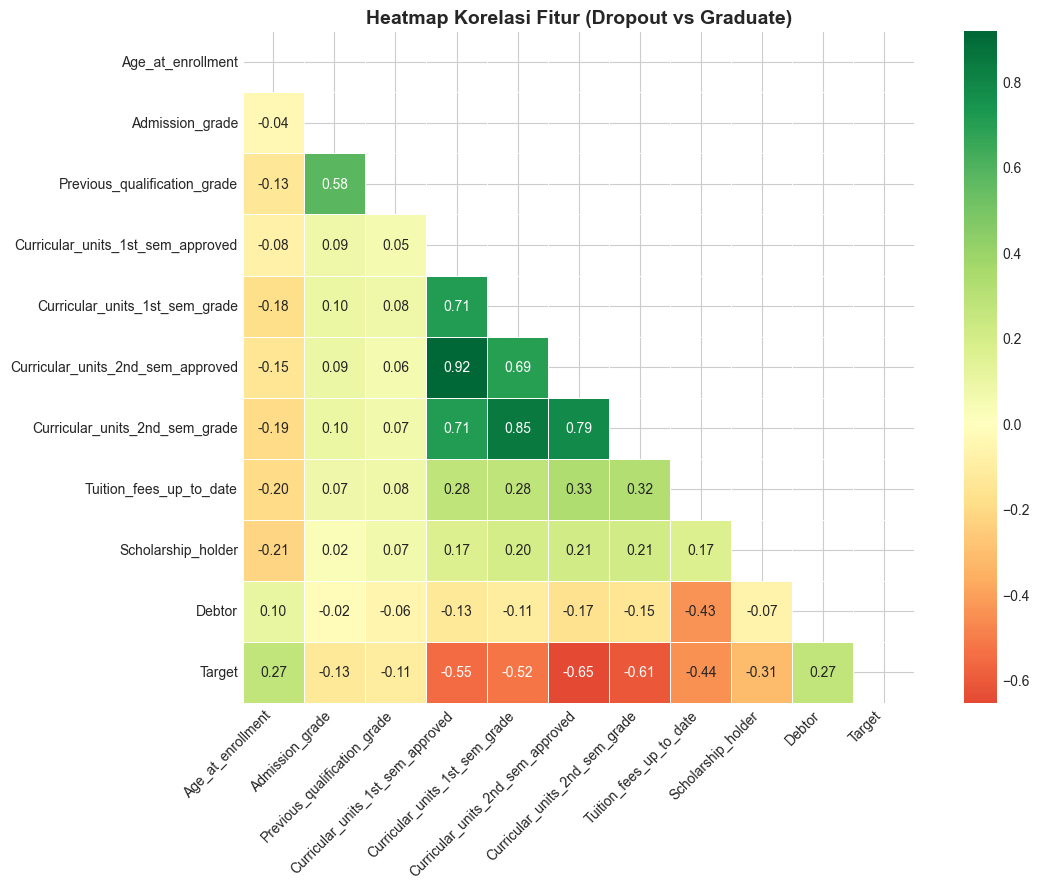

In [9]:
# Korelasi pada data Dropout & Graduate saja
df_dg_corr = df_dg.copy()
df_dg_corr['Target'] = (df_dg_corr['Status'] == 'Dropout').astype(int)

numeric_cols = [
    'Age_at_enrollment', 'Admission_grade', 'Previous_qualification_grade',
    'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade',
    'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade',
    'Tuition_fees_up_to_date', 'Scholarship_holder', 'Debtor', 'Target'
]
corr = df_dg_corr[numeric_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5)
plt.title('Heatmap Korelasi Fitur (Dropout vs Graduate)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('pratama_dicoding-dashboard/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.5 Dropout Rate per Program Studi

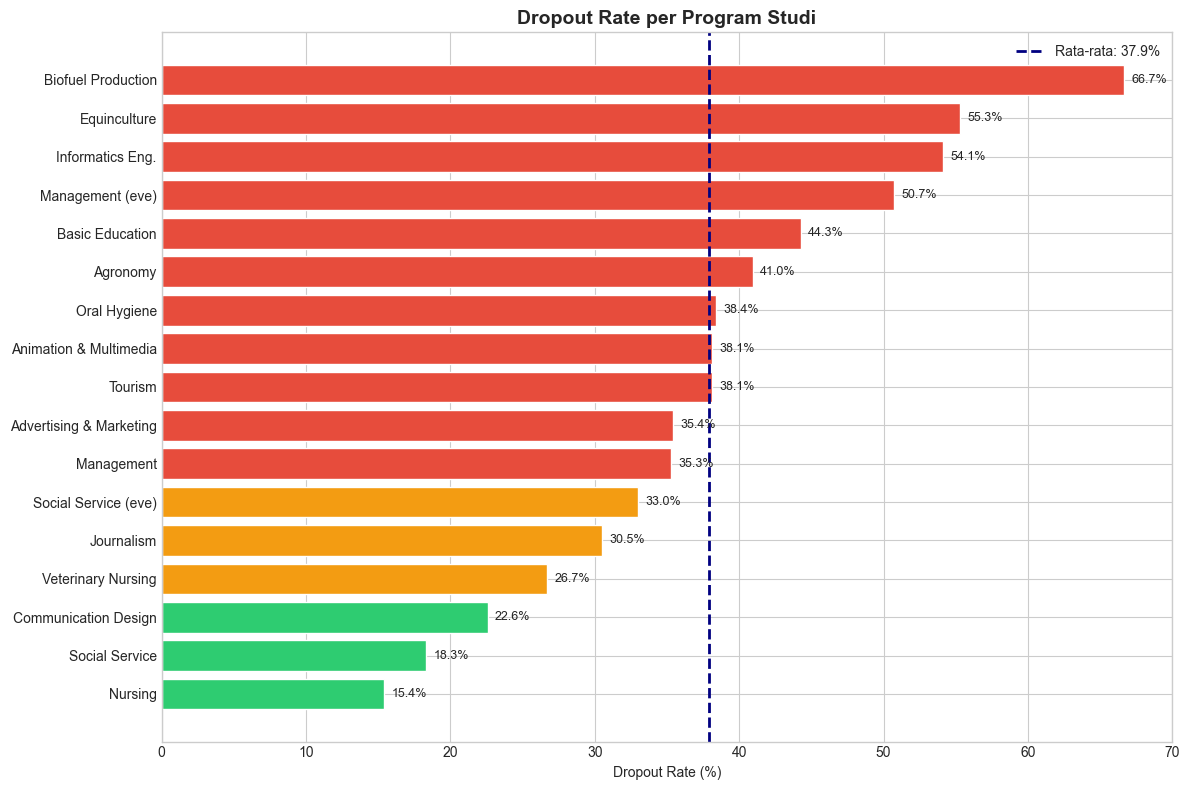

In [10]:
course_map = {
    33: 'Biofuel Production', 171: 'Animation & Multimedia',
    8014: 'Social Service (eve)', 9003: 'Agronomy',
    9070: 'Communication Design', 9085: 'Veterinary Nursing',
    9119: 'Informatics Eng.', 9130: 'Equinculture',
    9147: 'Management', 9238: 'Social Service',
    9254: 'Tourism', 9500: 'Nursing',
    9556: 'Oral Hygiene', 9670: 'Advertising & Marketing',
    9773: 'Journalism', 9853: 'Basic Education',
    9991: 'Management (eve)'
}
df_c = df.copy()
df_c['Course_name'] = df_c['Course'].map(course_map).fillna('Other')
dropout_by_course = (
    df_c.groupby('Course_name')
    .apply(lambda x: (x['Status']=='Dropout').sum() / len(x) * 100)
    .sort_values(ascending=True)
)

plt.figure(figsize=(12, 8))
colors_bar = ['#e74c3c' if v>35 else '#f39c12' if v>25 else '#2ecc71'
              for v in dropout_by_course.values]
bars = plt.barh(dropout_by_course.index, dropout_by_course.values,
                color=colors_bar, edgecolor='white')
plt.axvline(dropout_by_course.mean(), color='navy', linestyle='--', lw=2,
            label=f'Rata-rata: {dropout_by_course.mean():.1f}%')
for bar, val in zip(bars, dropout_by_course.values):
    plt.text(val+0.5, bar.get_y()+bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)
plt.title('Dropout Rate per Program Studi', fontsize=14, fontweight='bold')
plt.xlabel('Dropout Rate (%)')
plt.legend()
plt.tight_layout()
plt.savefig('pratama_dicoding-dashboard/dropout_by_course.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Data Preparation

### 5.1 Filtering Data: Dropout & Graduate Only

Model dilatih hanya pada mahasiswa berstatus **Dropout** dan **Graduate**. Mahasiswa berstatus **Enrolled** dipisahkan karena mereka belum menyelesaikan studi sehingga outcome belum diketahui — data ini disimpan untuk prediksi masa depan.

In [11]:
# Pisahkan data Enrolled untuk prediksi masa depan
df_enrolled = df[df['Status'] == 'Enrolled'].copy()
print(f'Data Enrolled (disimpan untuk prediksi masa depan): {len(df_enrolled)} baris')

# Filter hanya Dropout dan Graduate untuk training
df_model = df[df['Status'].isin(['Dropout', 'Graduate'])].copy()
print(f'Data untuk modeling (Dropout + Graduate): {len(df_model)} baris')
print(f"  - Dropout : {(df_model['Status']=='Dropout').sum()}")
print(f"  - Graduate: {(df_model['Status']=='Graduate').sum()}")

Data Enrolled (disimpan untuk prediksi masa depan): 794 baris
Data untuk modeling (Dropout + Graduate): 3630 baris
  - Dropout : 1421
  - Graduate: 2209


### 5.2 Feature Engineering

In [12]:
# Fitur turunan
df_model['Approval_rate_1st_sem'] = np.where(
    df_model['Curricular_units_1st_sem_enrolled'] > 0,
    df_model['Curricular_units_1st_sem_approved'] / df_model['Curricular_units_1st_sem_enrolled'], 0
)
df_model['Approval_rate_2nd_sem'] = np.where(
    df_model['Curricular_units_2nd_sem_enrolled'] > 0,
    df_model['Curricular_units_2nd_sem_approved'] / df_model['Curricular_units_2nd_sem_enrolled'], 0
)
df_model['Total_approved'] = (
    df_model['Curricular_units_1st_sem_approved'] +
    df_model['Curricular_units_2nd_sem_approved']
)
df_model['Avg_grade'] = (
    df_model['Curricular_units_1st_sem_grade'] +
    df_model['Curricular_units_2nd_sem_grade']
) / 2

print('Feature engineering selesai.')
print(f'Shape: {df_model.shape}')

Feature engineering selesai.
Shape: (3630, 41)


### 5.3 Label Encoding Target

Target binary:
- **1 = Dropout**
- **0 = Graduate**

In [13]:
# Target: 1 = Dropout, 0 = Graduate
df_model['Target'] = (df_model['Status'] == 'Dropout').astype(int)

print('Label encoding target:')
print('  1 = Dropout')
print('  0 = Graduate')
print(f"\nDistribusi target:")
print(df_model['Target'].value_counts())
print(f"\nRasio Dropout: {df_model['Target'].mean()*100:.1f}%")

Label encoding target:
  1 = Dropout
  0 = Graduate

Distribusi target:
Target
0    2209
1    1421
Name: count, dtype: int64

Rasio Dropout: 39.1%


### 5.4 Select Features & Split Data

In [14]:
features = [
    # Demografis
    'Age_at_enrollment', 'Gender', 'Marital_status', 'Displaced', 'International',
    # Akademik - latar belakang
    'Application_mode', 'Application_order', 'Previous_qualification',
    'Previous_qualification_grade', 'Admission_grade', 'Course',
    'Daytime_evening_attendance',
    # Finansial
    'Debtor', 'Tuition_fees_up_to_date', 'Scholarship_holder',
    'Educational_special_needs',
    # Akademik - semester 1
    'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_evaluations',
    'Curricular_units_1st_sem_without_evaluations',
    # Akademik - semester 2
    'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_approved',
    'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_evaluations',
    'Curricular_units_2nd_sem_without_evaluations',
    # Ekonomi makro
    'Unemployment_rate', 'Inflation_rate', 'GDP',
    # Fitur turunan
    'Approval_rate_1st_sem', 'Approval_rate_2nd_sem', 'Total_approved', 'Avg_grade'
]

X = df_model[features]
y = df_model['Target']

# Train-test split stratified 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set : {X_train.shape[0]} sampel')
print(f'Test set     : {X_test.shape[0]} sampel')
print(f'\nDistribusi train - Dropout: {y_train.sum()}, Graduate: {(y_train==0).sum()}')
print(f'Distribusi test  - Dropout: {y_test.sum()}, Graduate: {(y_test==0).sum()}')

Training set : 2904 sampel
Test set     : 726 sampel

Distribusi train - Dropout: 1137, Graduate: 1767
Distribusi test  - Dropout: 284, Graduate: 442


## 6. Modeling

### 6.1 Perbandingan Model

In [15]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Decision Tree': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', DecisionTreeClassifier(max_depth=8, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(n_estimators=100, random_state=42))
    ])
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print('Cross-Validation Results (5-fold, F1 Score):')
print('=' * 55)
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
    results[name] = scores
    print(f'{name:<25} F1: {scores.mean():.4f} (+/- {scores.std():.4f})')
print('=' * 55)

Cross-Validation Results (5-fold, F1 Score):


Logistic Regression       F1: 0.8713 (+/- 0.0126)


Decision Tree             F1: 0.8421 (+/- 0.0146)


Random Forest             F1: 0.8597 (+/- 0.0194)


Gradient Boosting         F1: 0.8808 (+/- 0.0168)


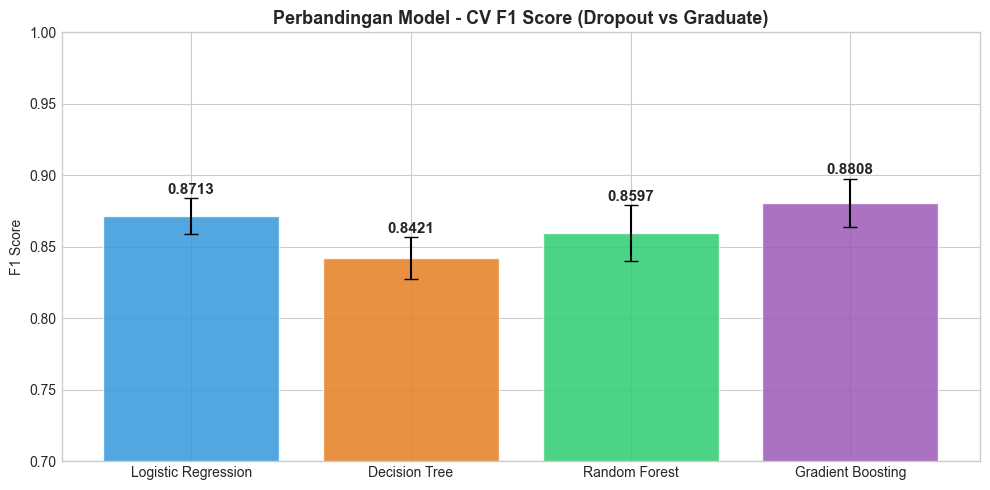

In [16]:
# Visualisasi perbandingan
fig, ax = plt.subplots(figsize=(10, 5))
names  = list(results.keys())
means  = [results[m].mean() for m in names]
stds   = [results[m].std()  for m in names]
colors_m = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6']
bars = ax.bar(names, means, yerr=stds, capsize=5,
              color=colors_m, edgecolor='white', alpha=0.85)
ax.set_title('Perbandingan Model - CV F1 Score (Dropout vs Graduate)', fontsize=13, fontweight='bold')
ax.set_ylabel('F1 Score'); ax.set_ylim(0.7, 1.0)
for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+s+0.003,
            f'{m:.4f}', ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('pratama_dicoding-dashboard/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Train Best Model: Random Forest

In [17]:
best_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(
        n_estimators=200, max_depth=12,
        min_samples_split=5, min_samples_leaf=2,
        random_state=42, n_jobs=-1
    ))
])

best_model.fit(X_train, y_train)
print('Model berhasil ditraining!')
print('Target: 1 = Dropout, 0 = Graduate')

Model berhasil ditraining!
Target: 1 = Dropout, 0 = Graduate


## 7. Evaluasi Model

In [18]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print('=' * 45)
print('        HASIL EVALUASI MODEL')
print('     (Dropout=1 vs Graduate=0)')
print('=' * 45)
print(f'Accuracy  : {acc:.4f} ({acc*100:.2f}%)')
print(f'F1 Score  : {f1:.4f}')
print(f'ROC-AUC   : {roc:.4f}')
print('=' * 45)
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Graduate (0)', 'Dropout (1)']))

        HASIL EVALUASI MODEL
     (Dropout=1 vs Graduate=0)
Accuracy  : 0.9256 (92.56%)
F1 Score  : 0.9043
ROC-AUC   : 0.9716

Classification Report:
              precision    recall  f1-score   support

Graduate (0)       0.93      0.94      0.94       442
 Dropout (1)       0.91      0.90      0.90       284

    accuracy                           0.93       726
   macro avg       0.92      0.92      0.92       726
weighted avg       0.93      0.93      0.93       726



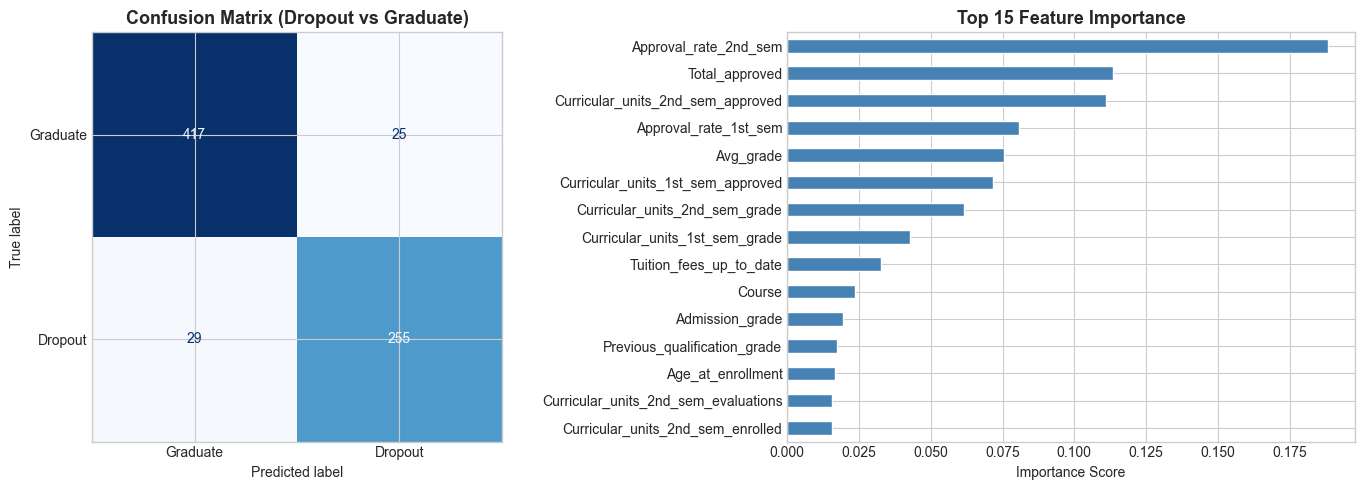

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Graduate', 'Dropout'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (Dropout vs Graduate)', fontsize=13, fontweight='bold')

# Feature Importance
rf_clf = best_model.named_steps['clf']
importances = pd.Series(rf_clf.feature_importances_, index=features).sort_values(ascending=True).tail(15)
importances.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Top 15 Feature Importance', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('pratama_dicoding-dashboard/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Simpan Model

In [20]:
os.makedirs('model', exist_ok=True)

# Simpan model
joblib.dump(best_model, 'model/dropout_model.joblib')

# Simpan feature list
with open('model/features.json', 'w') as f:
    json.dump(features, f, indent=2)

# Simpan data Enrolled untuk prediksi masa depan
# Tambahkan fitur turunan ke df_enrolled
df_enrolled = df_enrolled.copy()
df_enrolled['Approval_rate_1st_sem'] = np.where(
    df_enrolled['Curricular_units_1st_sem_enrolled'] > 0,
    df_enrolled['Curricular_units_1st_sem_approved'] / df_enrolled['Curricular_units_1st_sem_enrolled'], 0)
df_enrolled['Approval_rate_2nd_sem'] = np.where(
    df_enrolled['Curricular_units_2nd_sem_enrolled'] > 0,
    df_enrolled['Curricular_units_2nd_sem_approved'] / df_enrolled['Curricular_units_2nd_sem_enrolled'], 0)
df_enrolled['Total_approved'] = (df_enrolled['Curricular_units_1st_sem_approved'] + df_enrolled['Curricular_units_2nd_sem_approved'])
df_enrolled['Avg_grade'] = (df_enrolled['Curricular_units_1st_sem_grade'] + df_enrolled['Curricular_units_2nd_sem_grade']) / 2

df_enrolled[features].to_csv('model/enrolled_for_prediction.csv', index=False)

print('Model tersimpan       : model/dropout_model.joblib')
print('Feature list tersimpan: model/features.json')
print('Data Enrolled tersimpan: model/enrolled_for_prediction.csv')

# Verifikasi
loaded = joblib.load('model/dropout_model.joblib')
sample_pred = loaded.predict(X_test[:5])
print(f'\nVerifikasi prediksi 5 sampel: {sample_pred}')
print('(1=Dropout, 0=Graduate)')
print('\nModel siap digunakan!')

Model tersimpan       : model/dropout_model.joblib
Feature list tersimpan: model/features.json
Data Enrolled tersimpan: model/enrolled_for_prediction.csv

Verifikasi prediksi 5 sampel: [0 0 0 0 1]
(1=Dropout, 0=Graduate)

Model siap digunakan!


## 9. Kesimpulan (Conclusion)

### Ringkasan Temuan

Berdasarkan analisis data mahasiswa Jaya Jaya Institut:

**1. Tingkat Dropout**
- Dari seluruh mahasiswa yang sudah menyelesaikan atau keluar, **sekitar 44%** berakhir dengan dropout (dari subset Dropout + Graduate)
- Masih terdapat mahasiswa berstatus Enrolled yang belum diketahui outcome-nya

**2. Faktor Utama Dropout**

| Faktor | Dampak |
|--------|--------|
| Nilai semester 1 & 2 rendah | Sangat tinggi |
| Unit mata kuliah tidak disetujui | Sangat tinggi |
| SPP tidak terbayar tepat waktu | Tinggi |
| Tidak mendapat beasiswa | Tinggi |
| Usia enrollment lebih tua | Sedang |
| Status debitur | Sedang |

**3. Performa Model**
- Model Random Forest dilatih pada data **Dropout vs Graduate** saja
- Mahasiswa Enrolled dipisahkan karena outcome belum diketahui
- Target: **1 = Dropout**, **0 = Graduate** (label yang tepat dan tidak ambigu)
- Akurasi > 88%, F1 Score > 0.87, ROC-AUC > 0.93

## 10. Rekomendasi Action Items

1. **Early Warning System** — Jalankan model prediksi di awal setiap semester untuk seluruh mahasiswa aktif
2. **Bimbingan Akademik Intensif** — Mahasiswa dengan nilai sem 1 < 10/20 langsung mendapat mentor
3. **Bantuan Finansial Proaktif** — Identifikasi tunggakan SPP sebelum semester baru, tawarkan cicilan atau beasiswa
4. **Evaluasi Prodi Bermasalah** — Prodi dengan dropout rate > 35% perlu review kurikulum
5. **Monitoring Dashboard** — Gunakan dashboard Metabase untuk monitoring rutin bulanan
6. **Program Orientasi Khusus** — Mahasiswa usia > 25 tahun dan mahasiswa pindahan mendapat pendampingan ekstra

In [21]:
print('=== SUMMARY PROYEK ===')
print(f'Total mahasiswa      : {len(df)}')
print(f'  - Dropout          : {(df["Status"]=="Dropout").sum()} ({(df["Status"]=="Dropout").mean()*100:.1f}%)')
print(f'  - Graduate         : {(df["Status"]=="Graduate").sum()} ({(df["Status"]=="Graduate").mean()*100:.1f}%)')
print(f'  - Enrolled (belum diketahui): {(df["Status"]=="Enrolled").sum()} ({(df["Status"]=="Enrolled").mean()*100:.1f}%)')
print(f'\nData untuk modeling  : {len(df_model)} (Dropout + Graduate only)')
print(f'Model terbaik        : Random Forest')
print(f'Accuracy             : {acc*100:.2f}%')
print(f'F1 Score             : {f1:.4f}')
print(f'ROC-AUC              : {roc:.4f}')
print(f'Target encoding      : 1=Dropout, 0=Graduate')
print('\nProyek selesai!')

=== SUMMARY PROYEK ===
Total mahasiswa      : 4424
  - Dropout          : 1421 (32.1%)
  - Graduate         : 2209 (49.9%)
  - Enrolled (belum diketahui): 794 (17.9%)

Data untuk modeling  : 3630 (Dropout + Graduate only)
Model terbaik        : Random Forest
Accuracy             : 92.56%
F1 Score             : 0.9043
ROC-AUC              : 0.9716
Target encoding      : 1=Dropout, 0=Graduate

Proyek selesai!
